# Identification of factors

In this notebook, we use the already trained DRVI model on the immune dataset to show different ways to identify a factor. In summary we can:

- Identify based on available annotation
- Identify using GSEA
- Identify using Language models
- Looking into the annotation databases

**We always advise examination by a biologist or looking into the published litereture for validation of the identified processes.**

## Intro

In this notrbook, we assume that the user has already trained DRVI on Immune data.

Please refer to [General training and interpretability pipeline](./general_pipeline.html) tutorial.

## Contact

For questions and help requests, you can reach out in the [scverse discourse](https://discourse.scverse.org/).

If you found a bug, please use the [issue tracker](https://github.com/theislab/drvi/issues).

## Install

If you try DRVI on colab, next cell will install dependencies.

Please remove this part if your environment is already setup.

In [59]:
import sys

# if branch is stable, will install via pypi, else will install from source
branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    !pip install multigrate[tutorials]
elif IN_COLAB and branch != "stable":
    !pip install git+https://github.com/theislab/drvi.git#egg=drvi[tutorials]

## Imports

In [60]:
import warnings
warnings.filterwarnings("ignore")

In [61]:
import anndata as ad
import scanpy as sc

import scvi
import drvi
from pathlib import Path
from drvi.model import DRVI
from drvi.utils.misc import hvg_batch

In [62]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.0.post1
Last run with DRVI version: 0.2.1


## Config

In [63]:
# Set this to false if you already trained your model and do not like to retrain.
overwrite = False
SEED = 1  # Set to None if you don't want to set seed

# Set input output directory
# We use tmp_io/ directory in the same place as this notebook. Update accordingly.
io_dir = Path("./tmp_io/drvi_immune_128/")
io_dir.mkdir(parents=True, exist_ok=True)
io_dir

PosixPath('tmp_io/drvi_immune_128')

## Load Data

In [64]:
# We already saved pre-processed data in previous notebook
adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")

## Load DRVI ouputs

In [77]:
model_path = io_dir / "drvi_model"
embed_path = io_dir / "embed.h5ad"
traverse_adata_path = io_dir / "traverse_adata.h5ad"

model = DRVI.load(model_path, adata)
embed = sc.read_h5ad(embed_path)
traverse_adata = sc.read_h5ad(traverse_adata_path)

INFO     File tmp_io/drvi_immune_128/drvi_model/model.pt already downloaded                                        
INFO     DRVI: The model is trained with DRVI version 0.2.1.                                                       
INFO     DRVI: Loading source in DRVI version 0.2.1.                                                               
INFO     DRVI: The model has been initialized                                                                      


## Identify based on available annotations

In this dataset we have annotations stored in `adata.obs["final_annotation"]`.

We first measure Scaled Mutual Information (SMI) between each latent dimension and each category using DRVI built-in functions.

In [66]:
annot_col = "final_annotation"

### Specific Imports

In [67]:
import math
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

### Helper functions

In [68]:
def plot_packed_network(df, title_col='title', var_col='variable', val_col='value'):
    """
    Visualizes network with edge weights shown to 2 decimal places.
    """
    # Create Graph
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)
    
    # Custom Grid Layout Logic
    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = math.ceil(len(components)**0.5)
    
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=(14, 10))
    titles = set(df[title_col])
    
    # Draw Nodes & Edges
    nx.draw(G, pos, 
            with_labels=True, font_size=8, font_weight='bold', node_size=600,
            node_color=['#A0CBE2' if n in titles else '#FF9E9E' for n in G.nodes()],
            width=[d[val_col] * 4 for u, v, d in G.edges(data=True)], 
            edge_color='grey', alpha=0.6)
    
    # Draw Edge Labels (Weights rounded to 2 decimals)
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
            
    plt.axis('off')
    plt.show()

### Code

In [69]:
# Remove vanished dimensions
embed_nv = embed[:, embed.var['vanished'] == False].copy()
embed_nv

AnnData object with n_obs × n_vars = 32484 × 61
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', '_scvi_batch', '_scvi_labels'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [70]:
benchmark = DiscreteDisentanglementBenchmark(
    embed_nv.X, dim_titles=embed_nv.var['title'], discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc", "SPN"], aggregation_methods=["LMS"],
)
benchmark.evaluate()
# You can optionally save benchmark object if you want.
# benchmark.save(filename)
# benchmark = DiscreteDisentanglementBenchmark.load(filename, embed_nv.X, dim_titles=embed_nv.var['title'], discrete_target=embed.obs["final_annotation"], metrics=["SMI-disc", "SPN"], aggregation_methods=["LMS"])

In [71]:
smi_similarity = benchmark.get_results_details()["SMI-disc"]
smi_similarity[:5]  # only showing 5 rows

,CD4+ T cells,CD8+ T cells,CD10+ B cells,CD14+ Monocytes,CD16+ Monocytes,CD20+ B cells,Erythrocytes,Erythroid progenitors,HSPCs,Megakaryocyte progenitors,Monocyte progenitors,Monocyte-derived dendritic cells,NK cells,NKT cells,Plasma cells,Plasmacytoid dendritic cells
title,,,,,,,,,,,,,,,,
DR 36,0.021124,0.007055,0.013579,0.005682,0.003340,0.006009,0.012808,0.025647,0.141675,0.147504,0.652945,0.023091,0.009346,0.006856,0.019912,0.010587
DR 49,0.058937,0.010312,0.003151,0.115108,0.019689,0.012800,0.006262,0.002189,0.002379,0.001219,0.001292,0.004543,0.008689,0.017035,0.859131,0.003900
DR 33,0.030350,0.011059,0.030578,0.021986,0.009531,0.011717,0.048552,0.468666,0.061815,0.370950,0.022623,0.007081,0.010243,0.011877,0.009066,0.005726
DR 38,0.017637,0.007678,0.008826,0.008149,0.012777,0.123699,0.004518,0.050416,0.004173,0.049967,0.008930,0.026165,0.005970,0.006707,0.018673,0.009291
DR 2,0.140299,0.080318,0.033397,0.761070,0.048512,0.084590,0.070976,0.036295,0.033788,0.033796,0.033385,0.107270,0.063494,0.064894,0.035367,0.038994


In [72]:
filtering_threshold = 0.5

top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars='title', value_vars=smi_similarity.columns)
    .query("value >= @filtering_threshold")
    .reset_index(drop=True)
)
top_matches

,title,variable,value
0,DR 1,CD4+ T cells,0.535119
1,DR 41,CD10+ B cells,0.668039
2,DR 53,CD10+ B cells,0.773828
3,DR 31,CD10+ B cells,0.659314
4,DR 2,CD14+ Monocytes,0.761070
5,DR 3,CD14+ Monocytes,0.878655
6,DR 26,CD16+ Monocytes,0.661827
7,DR 9,CD16+ Monocytes,0.910748
8,DR 5,CD20+ B cells,0.758002
9,DR 7,CD20+ B cells,0.654006


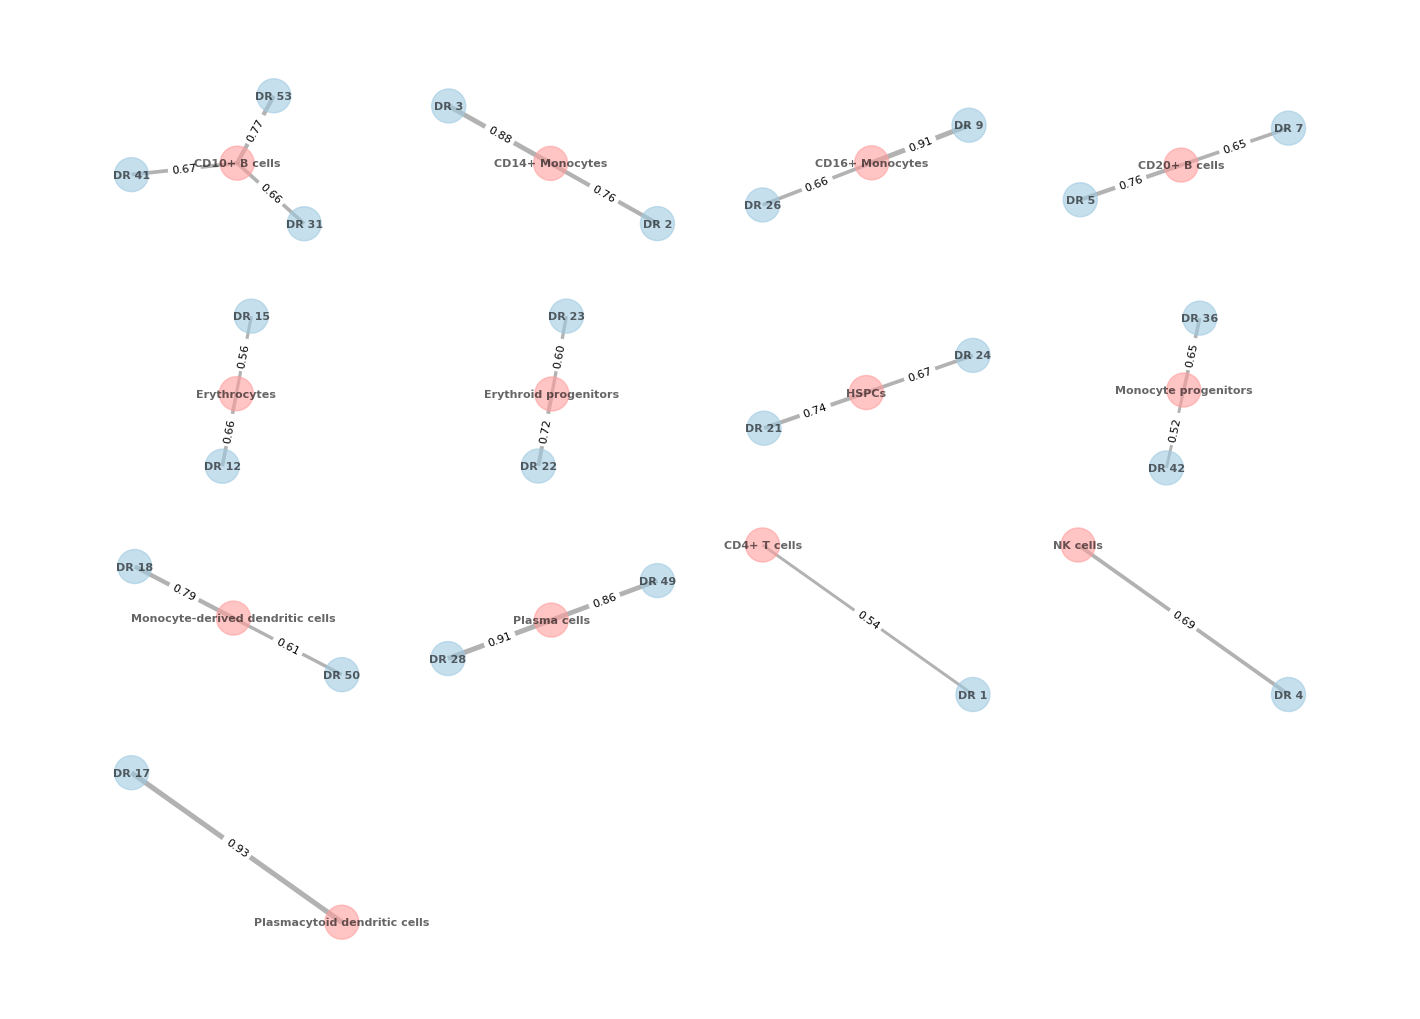

In [42]:
plot_packed_network(top_matches)

#### Heatmap

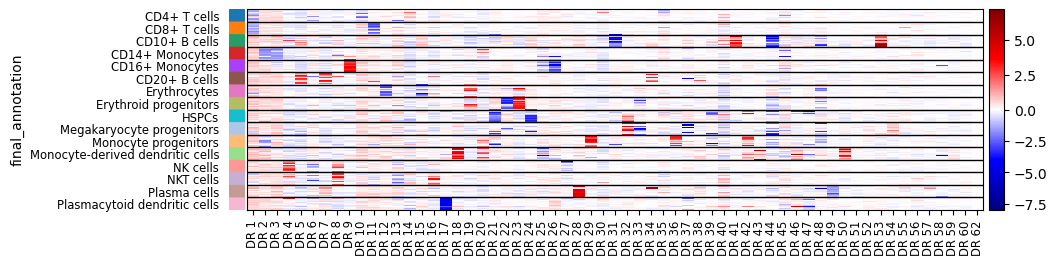

In [43]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, "final_annotation", title_col="title")

It is possible to sort dimensions based on the top relevance with respect to a categoricals variable

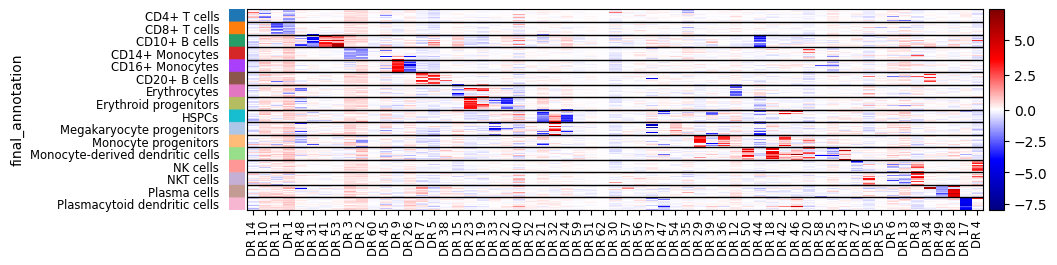

In [44]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, "final_annotation", title_col="title", sort_by_categorical=True)

## Identification of programs

Once we identify the top relevant genes, we can determine some programs through supervised external information, such as:
- existing annotations
- examination by biologists
- gene-set enrichment analysis (GSEA)
- scientific literature
- automated tools based on language models

**Please refer to this tutorial for some tools that we found useful for identification of programs**

It is worth mentioning that since such supervised information is not given to the model, the quality of the derived signatures is neither affected nor biased by it. Unidentified processes with high gene scores are promising candidates for further literature search, additional analysis, and even experimental design.

1. Input: 
-Gene list?
-Ranked list?
Expression Correlation with known Zelltype Markers
2. Reference Databases: 
-Classic Datatabases: Gene Ontology, Reactome, MSigDB? 
-Celltype specific Data (Cell Typist)
-LLMs: gsai?
3. Annotation Method:
-Over-representation
-Regressions based: How well does a set of genes explain a factor




# Exploration Roadmap: DRVI Factor Annotation Pipeline

## General Roadmap Settings


### General Configurations

In [169]:
filter_vanished = True
factor_id_col = "title"   # keeps factor labels stable across tools (e.g. "DR 36")

# Comparison thresholds
corr_threshold = 0.4
spec_threshold = 0.1
gsea_fdr_threshold = 0.05

This roadmap outlines the systematic evaluation of tools for annotating latent factors. The goal is to move from abstract dimensions to interpretable biological processes using the immune dataset as a pilot.

### Shared Data Setup

In [170]:
import celltypist
from celltypist import models
import blitzgsea as blitz
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Sync Cells


In [ ]:
# make sure indices of adata and embed are the same
common_cells = adata.obs_names.intersection(embed_full.obs_names)
adata = adata[common_cells].copy()
embed_full = embed_full[common_cells].copy()
print(f"Cells: {adata.n_obs}")

Cells: 32484


### Factor Filter


In [ ]:
if filter_vanished and 'vanished' in embed_full.var.columns:
    mask = ~embed_full.var['vanished'].astype(bool).values
else:
    mask = np.ones(embed_full.n_vars, dtype=bool)
embed = embed_full[:, mask].copy()
print(f"Factors used: {embed.n_vars} | filter_vanished={filter_vanished}")

Factors used: 61 | filter_vanished=True


### Standardized Factor IDs

In [173]:
if factor_id_col not in embed.var.columns:
    embed.var[factor_id_col] = [f"Factor_{i}" for i in range(embed.n_vars)]
factor_ids = embed.var[factor_id_col].astype(str).tolist()

## 1. Statistical Annotation & Similarity 

Goal: Map latent factors to known cell types using existing annotations and atlases.

Tools to Compare:
* CellTypist: Utilizing the Immune_All_Low.pkl or High models for automated labeling.

Key Metrics:


### 1.1 Cell Typist

* Input: normalized gene expression matrix of cells
* Reference: Pre-trained Logistic Regression models trained on millions of annotated cells in different tissues
* Algorithm: Linear Classification --> Calculates Decision Scores via linear combination of scaled expression and model coefficients, followed by a Maximum Score selection for identity.
* Output: 
    * Predicted Labels: Final call for each cell
    * Decision Matrix: Raw classification scores
    * Probability Matrix: Sigmoid-transformed scores (0 to 1)





#### CellTypist Model

In [ ]:
#download celltypist model
print(models.models_description())
model_name = 'Immune_All_Low.pkl'
models.download_models(force_update=True, model=model_name)
ct_model = models.Model.load(model=model_name)

#load recommended model for immune cells
ct_model = models.Model.load(model=model_name)
print(model.cell_types)

📂 Storing models in /Users/clara.sanchez/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)


#### CellTypist Annotation


In [175]:
# Annotate cell types using CellTypist
predictions = celltypist.annotate(adata, model=model_name, majority_voting=True)

adata.obs['celltypist_labels'] = predictions.predicted_labels['predicted_labels']

adata.obs['celltypist_majority'] = predictions.predicted_labels['majority_voting']

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 32484 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1569 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


#### Extract Probability Matrix

In [176]:
# The Probability Matrix contains sigmoid-transformed scores (0 to 1)
# This is the primary input for the factor correlation analysis
prob_matrix = predictions.probability_matrix
prob_matrix.index = adata.obs_names

# Quick check: How many cell types did the model find?
print(f"Modell knows {prob_matrix.shape[1]} different Immune cell types.")

Modell knows 98 different Immune cell types.


#### CellTypist Factor Correlation 

In [ ]:
drvi_factors = pd.DataFrame(embed.X, index=embed.obs_names, columns=factor_ids)

# correlation: factor vs CellTypist class probabilities
eval_matrix = pd.DataFrame(
    np.corrcoef(drvi_factors.T, prob_matrix.T)[:drvi_factors.shape[1], drvi_factors.shape[1]:],
    index=drvi_factors.columns,
    columns=prob_matrix.columns,
)

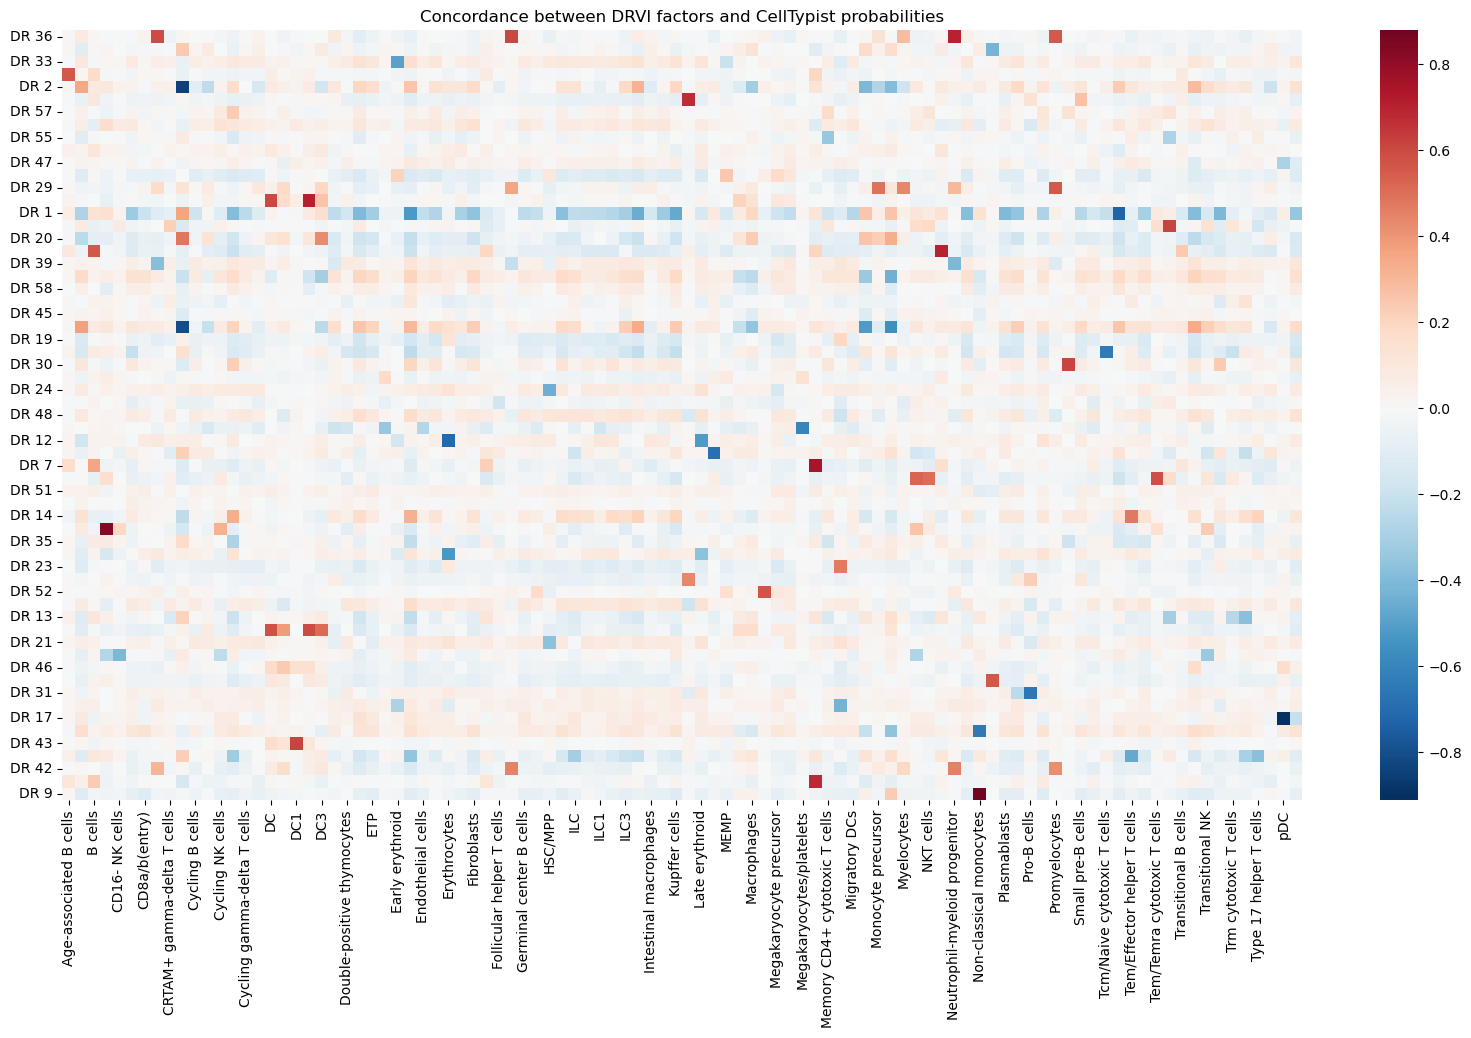

In [178]:
#Visualize the correlation matrix as a heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(eval_matrix, cmap='RdBu_r', center=0)
plt.title("Concordance between DRVI factors and CellTypist probabilities")
plt.show()

#### CellTypist Summary

In [180]:
# top and second-best label per factor
top_1 = eval_matrix.idxmax(axis=1)
top_1_val = eval_matrix.max(axis=1)
tmp = eval_matrix.copy()
for i, c in enumerate(top_1):
    tmp.iloc[i, tmp.columns.get_loc(c)] = -1

# Calculate specificity as the difference between top and second-best correlation
specificity = top_1_val - tmp.max(axis=1)


#Summarize results in a DataFrame
celltypist_summary = pd.DataFrame({
    'Factor': eval_matrix.index,
    'Top_CellType': top_1.values,
    'Correlation': top_1_val.values,
    'Specificity': specificity.values,
})

celltypist_summary['Tool'] = 'celltypist'
celltypist_summary['Label_std'] = celltypist_summary['Top_CellType'].astype(str).str.lower().str.replace(r'[^a-z0-9]+', '_', regex=True).str.strip('_')
celltypist_summary['Significant'] = (
    (celltypist_summary['Correlation'] >= corr_threshold)
    & (celltypist_summary['Specificity'] >= spec_threshold)
)
display(celltypist_summary[celltypist_summary['Significant']].head(20))

,Factor,Top_CellType,Correlation,Specificity,Tool,Label_std,Significant
3,DR 38,Age-associated B cells,0.558240,0.364309,celltypist,age_associated_b_cells,True
5,DR 41,Large pre-B cells,0.670493,0.403575,celltypist,large_pre_b_cells,True
13,DR 50,DC2,0.710290,0.105010,celltypist,dc2,True
15,DR 16,Tem/Trm cytotoxic T cells,0.618886,0.402161,celltypist,tem_trm_cytotoxic_t_cells,True
17,DR 5,Naive B cells,0.700203,0.138204,celltypist,naive_b_cells,True
26,DR 30,Regulatory T cells,0.615632,0.375146,celltypist,regulatory_t_cells,True
34,DR 7,Memory B cells,0.748783,0.392919,celltypist,memory_b_cells,True
38,DR 14,Tem/Effector helper T cells,0.475283,0.144239,celltypist,tem_effector_helper_t_cells,True
39,DR 4,CD16+ NK cells,0.834108,0.511472,celltypist,cd16_nk_cells,True
42,DR 23,Mid erythroid,0.471308,0.379061,celltypist,mid_erythroid,True


## 2. Gene Set Enrichment Analysis (Functional Identity)

Goal: Identify biological processes (e.g., "Interferon Response", "Cell Cycle") for factors that do not map 1-to-1 to a cell type.

Tools to Compare:
* gProfiler (gprofiler-official): The benchmark used in the DRVI preprint
* Gseapy: Python implementation for local Enrichment analysis (Enrichr/MSigDB)
* Decoupler: A fast framework for footprint-based enrichment (e.g., PROXIMA)
* Blitzqseq

Key Metrics:

### 2.1 Blitzqseq

How it works:
* Input: Ranked gene list (list of all genes sorted by loadings for a specific factor)
* Reference: MSigDB
    * Key Collections:
        * H (Hallmark): Broad biological states (e.g., "Hypoxia", "Inflammatory Response").
        * C5 (GO): Highly specific Gene Ontology terms.
        * C2 (CP): Curated pathways from Reactome or KEGG.
* Algorithm: 
    * Pre-ranking: Unlike standard GSEA which compares groups of cells, this version only looks at the ranking of genes
    * It calculates an Enrichment Score (ES) that increases when genes from a specific pathway appear at the top of your ranked list (high loadings)
    * Speed Optimization: BlitzGSEA uses a probability distribution approximation to estimate the null model. Instead of running thousands of slow permutations for every gene set, it uses mathematical shortcuts to calculate p-values almost instantly
* Output: 
    * NES (Normalized Enrichment Score): A high positive NES indicates that the biological process is strongly represented by that factor
    * p-value & FDR (q-value): Statistical significance. Usually, you filter for FDR<0.05
    * Leading Edge Genes: The specific subset of genes within a pathway that actually drove the enrichment score

#### BlitzGSEA Library

In [162]:
# MSigDB Hallmark is the gold standard for the first evaluation
signature_lib = blitz.enrichr.get_library("MSigDB_Hallmark_2020")

#### BlitzGSEA Scores (from latent dimensions)

In [ ]:
# Use full rankings, both directions
pos_df = traverse_adata.varm["max_possible_traverse_effect_pos"].copy()
neg_df = traverse_adata.varm["max_possible_traverse_effect_neg"].copy()
pos_df.columns = pos_df.columns.astype(str)
neg_df.columns = neg_df.columns.astype(str)

#Name mapping from factor IDs to titles (e.g. "DR 36")
dimid_to_title = (
    embed.var[["original_dim_id", factor_id_col]]
    .assign(original_dim_id=lambda d: d["original_dim_id"].astype(str),
            factor_id=lambda d: d[factor_id_col].astype(str))
    .drop_duplicates("original_dim_id")
    .set_index("original_dim_id")["factor_id"]
    .to_dict()
)
# only keep factors that are in both pos and neg and have a title
raw_ids = [rid for rid in pos_df.columns if rid in neg_df.columns and rid in dimid_to_title] 

# Combine pos and neg scores, and rename columns to include direction and factor titles
scores_df = pd.concat([pos_df[raw_ids].add_suffix("+"), neg_df[raw_ids].add_suffix("-")], axis=1)
scores_df.columns = [f"{dimid_to_title[c[:-1]]}{c[-1]}" for c in scores_df.columns if c[:-1] in dimid_to_title]
print(f"GSEA inputs: {scores_df.shape[1]} factor-directions")

print(f"GSEA inputs from DRVI framework: {len(gsea_inputs)} factor-directions")

GSEA inputs: 122 factor-directions
GSEA inputs from DRVI framework: 66 factor-directions


##### GSEA

In [ ]:
blitzgsea_results = [] # to store results
for factor_dir in scores_df.columns:
    try:
        signature = scores_df[factor_dir].rename("v").reset_index().rename(columns={"index": "i"}) # blitzgsea expects columns "i" and "v"
        signature["v"] = pd.to_numeric(signature["v"], errors="coerce") # ensure numeric and coerce errors to NaN
        signature = signature.replace([np.inf, -np.inf], np.nan).dropna(subset=["v"])
        res = blitz.gsea(signature, signature_lib, processes=4) # run GSEA with parallelization
        sig = res[res["fdr"] < gsea_fdr_threshold].sort_values("fdr") # filter significant results and sort by FDR
        if len(sig): # if there are significant results, take the top one, else record as no significant enrichment
            blitzgsea_results.append({
                "FactorDir": factor_dir,
                "Factor": factor_dir[:-1],
                "Direction": factor_dir[-1],
                "Term": sig.index[0],
                "NES": float(sig.iloc[0]["nes"]),
                "FDR": float(sig.iloc[0]["fdr"]),
            })
        else:
            blitzgsea_results.append({"FactorDir": factor_dir, "Factor": factor_dir[:-1], "Direction": factor_dir[-1], "Term": "No significant enrichment", "NES": 0.0, "FDR": 1.0})
    except Exception as e: # if any error occurs (e.g. due to bad input), record it and continue with the next factor
        blitzgsea_results.append({"FactorDir": factor_dir, "Factor": factor_dir[:-1], "Direction": factor_dir[-1], "Term": f"ERROR: {type(e).__name__}", "NES": 0.0, "FDR": 1.0})

blitzgsea_summary = pd.DataFrame(blitzgsea_results) 
display(blitzgsea_summary.head(60))

,FactorDir,Factor,Direction,Term,NES,FDR
0,DR 36+,DR 36,+,No significant enrichment,0.000000,1.000000
1,DR 49+,DR 49,+,No significant enrichment,0.000000,1.000000
2,DR 33+,DR 33,+,TNF-alpha Signaling via NF-kB,3.666940,0.011783
3,DR 38+,DR 38,+,No significant enrichment,0.000000,1.000000
4,DR 2+,DR 2,+,No significant enrichment,0.000000,1.000000
5,DR 41+,DR 41,+,No significant enrichment,0.000000,1.000000
6,DR 57+,DR 57,+,No significant enrichment,0.000000,1.000000
7,DR 59+,DR 59,+,No significant enrichment,0.000000,1.000000
8,DR 55+,DR 55,+,No significant enrichment,0.000000,1.000000
9,DR 62+,DR 62,+,No significant enrichment,0.000000,1.000000


#### BlitzGSEA Summary

In [ ]:
# Create a summary of significant GSEA results
annotated = blitzgsea_summary[blitzgsea_summary["FDR"] < gsea_fdr_threshold].copy()

#Calculate key performance indicators

# how many percent of latent factors got at least one significant annotation?
coverage = 100 * len(annotated) / len(blitzgsea_summary) if len(blitzgsea_summary) else 0 
print(f"Coverage (FDR<{gsea_fdr_threshold}): {coverage:.2f}% ({len(annotated)}/{len(blitzgsea_summary)})")

# how many unique terms were found? This indicates the diversity of biological processes captured by the factors.
print(f"Unique terms: {annotated['Term'].nunique()}")

# Normalized Enrichment Score. A value above 2 is generally considered strong evidence of enrichment. The median NES gives a sense of the overall strength of the annotations.
print(f"Median NES: {annotated['NES'].median():.2f}" if len(annotated) else "Median NES: n/a")

Coverage (FDR<0.05): 10.66% (13/122)
Unique terms: 7
Median NES: 3.37


,FactorDir,Term,NES,FDR
90,DR 60-,TNF-alpha Signaling via NF-kB,4.078342,2.177186e-03
21,DR 40+,TNF-alpha Signaling via NF-kB,4.050834,2.449701e-03
2,DR 33+,TNF-alpha Signaling via NF-kB,3.666940,1.178258e-02
107,DR 13-,Allograft Rejection,3.535420,1.954214e-02
103,DR 23-,TNF-alpha Signaling via NF-kB,3.520930,2.064173e-02
83,DR 45-,Interferon Gamma Response,3.438708,2.805586e-02
15,DR 16+,Allograft Rejection,3.366820,3.649933e-02
67,DR 57-,TNF-alpha Signaling via NF-kB,3.304859,4.561159e-02
42,DR 23+,heme Metabolism,3.168352,4.713445e-02
82,DR 40-,TNF-alpha Signaling via NF-kB,-3.340588,4.012863e-02


#### Preparation Cross Tool Comparison

In [ ]:
blitzgsea_tool_summary = blitzgsea_summary.copy()
blitzgsea_tool_summary["Tool"] = "blitzgsea"
blitzgsea_tool_summary["Label"] = blitzgsea_tool_summary["Term"].astype(str)
blitzgsea_tool_summary["Label_std"] = blitzgsea_tool_summary["Label"].str.lower().str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_")
blitzgsea_tool_summary["Significant"] = blitzgsea_tool_summary["FDR"] < gsea_fdr_threshold

display(annotated.sort_values("NES", ascending=False).head(20))

#### Cross Tool Comparison

In [ ]:
# Preparation of Cell-Typist Data for Comparison
ct_sig = celltypist_summary[celltypist_summary['Significant']][['Factor', 'Label_std', 'Correlation', 'Specificity']]
ct_sig = ct_sig.rename(columns={'Label_std': 'CellTypist_Label'})

#Filter significant GSEA results
gs_sig = (
    blitzgsea_tool_summary[blitzgsea_tool_summary['Significant']]
    .sort_values(['FDR', 'NES'], ascending=[True, False])
    .drop_duplicates('Factor')
    [['Factor', 'Direction', 'Label_std', 'NES', 'FDR']]
    .rename(columns={'Label_std': 'BlitzGSEA_Label'})
)

# Merge CellTypist and BlitzGSEA results on Factor
comparison = ct_sig.merge(gs_sig, on='Factor', how='outer')
comparison['Relationship'] = np.where(
    comparison['CellTypist_Label'].isna(),
    'blitzgsea_only', # if CellTypist label is missing but GSEA gives a result it's a BlitzGSEA-only annotation
    np.where(
        comparison['BlitzGSEA_Label'].isna(),
        'celltypist_only', #factor is a cell type
        np.where(comparison['CellTypist_Label'] == comparison['BlitzGSEA_Label'], 'same_label', 'complementary') #both tools give an annotation, if they match it's "same_label", else it's "complementary"
    )
)

print("Cross-tool relationship counts:")
display(comparison['Relationship'].value_counts()) 
display(comparison.sort_values(['Relationship', 'Factor']).head(50))

Cross-tool relationship counts:


Relationship
celltypist_only    13
blitzgsea_only      8
complementary       3
Name: count, dtype: int64

,Factor,CellTypist_Label,Correlation,Specificity,Direction,BlitzGSEA_Label,NES,FDR,Relationship
0,DR 13,NaN,NaN,NaN,-,allograft_rejection,3.535420,1.954214e-02,blitzgsea_only
2,DR 15,NaN,NaN,NaN,-,protein_secretion,-12.675488,3.881011e-35,blitzgsea_only
7,DR 33,NaN,NaN,NaN,+,tnf_alpha_signaling_via_nf_kb,3.666940,1.178258e-02,blitzgsea_only
11,DR 40,NaN,NaN,NaN,+,tnf_alpha_signaling_via_nf_kb,4.050834,2.449701e-03,blitzgsea_only
14,DR 44,NaN,NaN,NaN,-,wnt_beta_catenin_signaling,-5.752036,4.232391e-07,blitzgsea_only
15,DR 45,NaN,NaN,NaN,-,interferon_gamma_response,3.438708,2.805586e-02,blitzgsea_only
20,DR 57,NaN,NaN,NaN,-,tnf_alpha_signaling_via_nf_kb,3.304859,4.561159e-02,blitzgsea_only
21,DR 60,NaN,NaN,NaN,-,tnf_alpha_signaling_via_nf_kb,4.078342,2.177186e-03,blitzgsea_only
1,DR 14,tem_effector_helper_t_cells,0.475283,0.144239,NaN,NaN,NaN,NaN,celltypist_only
5,DR 28,plasma_cells,0.560665,0.463293,NaN,NaN,NaN,NaN,celltypist_only


#### 2.2 Gseapy

### 3. Language Model Based Identification (Advanced Annotation)

Goal: Automate "narrative" annotation and validation using LLMs.

Tools to Compare:
* gsai (Gene Set AI): Specialized LLM tool for gene list interpretation.
* Direct LLM Prompting: Using GPT-4/Claude via API to summarize factor-defining genes.
* OpenScholar: For literature-backed validation of the proposed factor names.

Key Metrics:

### 4. Final Integration & Verification

Goal: Create the final notebook structure to guide the user.

Implementation:
* Unified API: A single function to call all three categories and present a summary table.
* Verify Cells: Visual sanity checks (UMAPs + Dotplots) to verify that a factor's activity matches the assigned name.
* Filtering: Automating the exclusion of "Vanished Factors" (max absolute value < 1) to reduce noise.